<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Machine-Learning/blob/main/Indian_Liver_Patient_using_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
import pandas as pd
data =pd.read_csv('indian_liver_patient.csv')
data.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
print("Missing values:")
print(data.isnull().sum())
data = data.dropna() # Assign the result of dropna back to data

y = data['Dataset']

Missing values:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64


In [ ]:
# Ensure data is clean before separating features (X) and target (y)
# This addresses the ValueError if NaNs persisted during feature selection
data_cleaned = data.dropna().copy()

# Define features (X) by dropping the 'Dataset' column and handling 'Gender'
X = data_cleaned.drop('Dataset', axis=1)
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# Define target (y) and map values to 0 and 1
# Assuming 'Dataset' column contains values 1 (patient) and 2 (non-patient)
y = data_cleaned['Dataset'].apply(lambda x: 1 if x == 1 else 0)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# y_train and y_test already contain the numerical target labels and should not be scaled.

In [ ]:
log_reg_model=LogisticRegression()
log_reg_model.fit(X_train_scaled,y_train)

LogisticRegression()

In [ ]:
y_pred=log_reg_model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Model Accuracy: 0.6552
Confusion Matrix:
[[ 4 39]
 [ 1 72]]


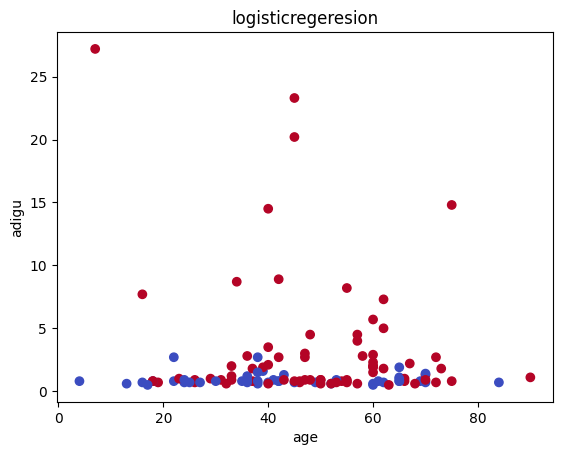

In [ ]:
plt.scatter(X_test.iloc[:,0],X_test.iloc[:,1],c=y_test,cmap='coolwarm')
plt.title('logisticregeresion')
plt.xlabel('age')
plt.ylabel('adigu')
plt.show()